In [11]:
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import time

fred = Fred(api_key='72e6c8e1a05483ce43998d5e0cc92465')

gs2 = fred.get_series('GS2', observation_start='2000-01-01')
gs10 = fred.get_series('GS10', observation_start='2000-01-01')

print("2Y:", gs2.tail(3))
print("10Y:", gs10.tail(3))

2Y: 2026-03-01    3.71
2026-04-01    3.80
2026-05-01    4.00
dtype: float64
10Y: 2026-03-01    4.25
2026-04-01    4.32
2026-05-01    4.48
dtype: float64


In [3]:
df = pd.DataFrame({'GS2': gs2, 'GS10': gs10})
df = df.dropna() 

df['spread'] = df['GS10'] - df['GS2']

df['inverted'] = df['spread'] < 0

print(df.tail(5))
print(f"\nCurrent spread: {df['spread'].iloc[-1]:.2f}%p")
print(f"Currently inverted: {df['inverted'].iloc[-1]}")

             GS2  GS10  spread  inverted
2026-01-01  3.54  4.21    0.67     False
2026-02-01  3.47  4.13    0.66     False
2026-03-01  3.71  4.25    0.54     False
2026-04-01  3.80  4.32    0.52     False
2026-05-01  4.00  4.48    0.48     False

Current spread: 0.48%p
Currently inverted: False


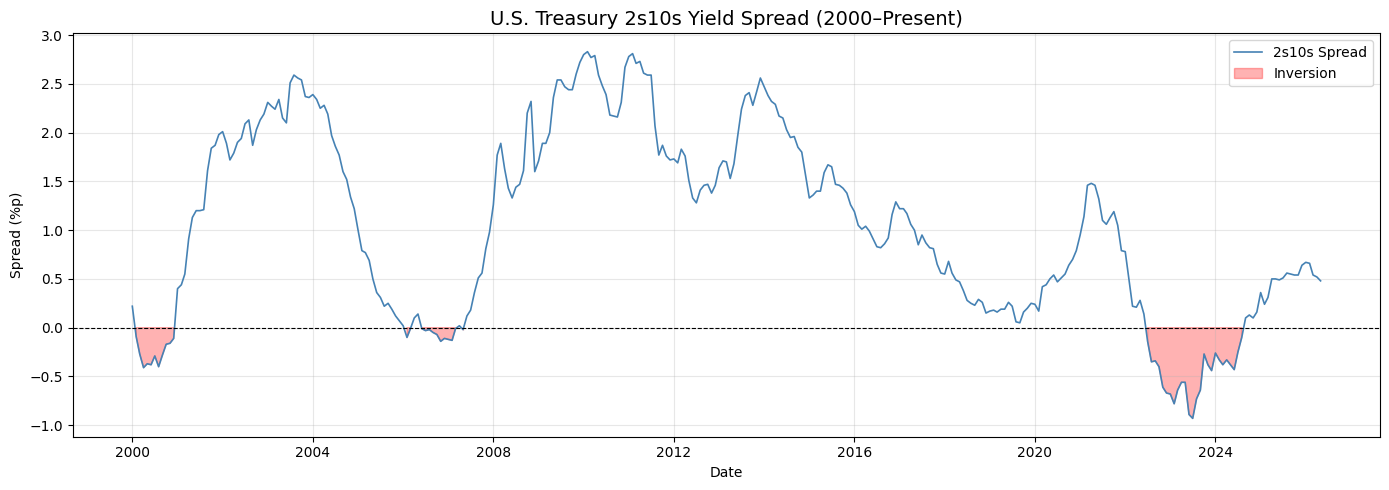

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['spread'], color='steelblue', linewidth=1.2, label='2s10s Spread')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.fill_between(df.index, df['spread'], 0,
                where=df['inverted'],
                color='red', alpha=0.3, label='Inversion')

ax.set_title('U.S. Treasury 2s10s Yield Spread (2000–Present)', fontsize=14)
ax.set_ylabel('Spread (%p)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

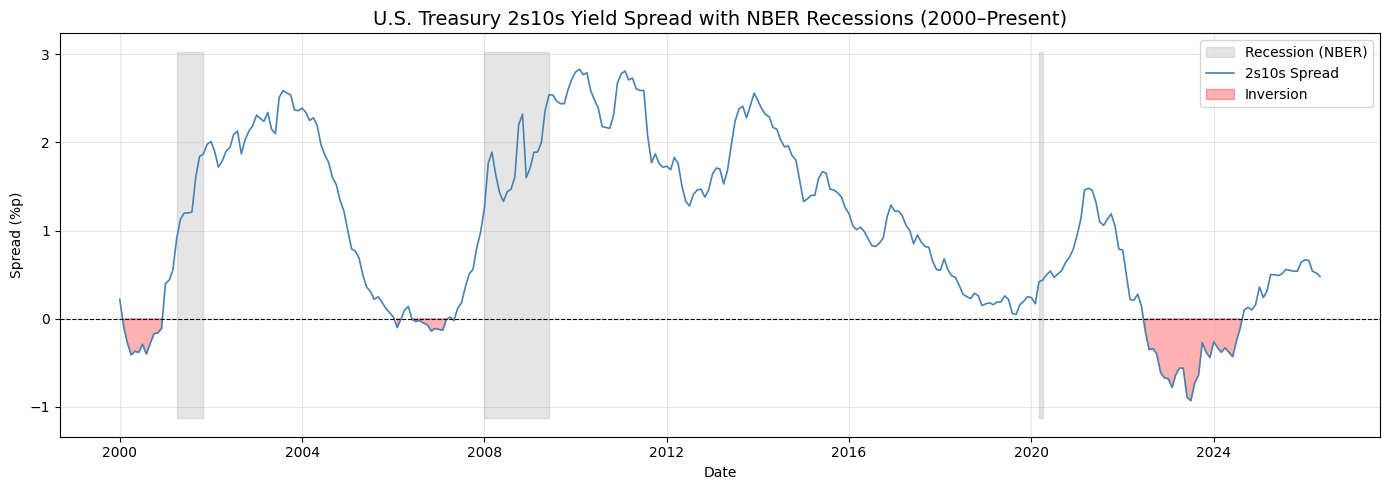

In [7]:
recession = fred.get_series('USREC', observation_start='2000-01-01')

df['recession'] = recession
df['recession'] = df['recession'].fillna(0)  

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df.index, df['spread'].min() - 0.2, df['spread'].max() + 0.2,
                where=df['recession'] == 1,
                color='gray', alpha=0.2, label='Recession (NBER)')

ax.plot(df.index, df['spread'], color='steelblue', linewidth=1.2, label='2s10s Spread')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.fill_between(df.index, df['spread'], 0,
                where=df['inverted'],
                color='red', alpha=0.3, label='Inversion')

ax.set_title('U.S. Treasury 2s10s Yield Spread with NBER Recessions (2000–Present)', fontsize=14)
ax.set_ylabel('Spread (%p)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
maturities = {
    '3M': 'GS3M',
    '1Y': 'GS1',
    '2Y': 'GS2',
    '5Y': 'GS5',
    '7Y': 'GS7',
    '10Y': 'GS10',
    '20Y': 'GS20',
    '30Y': 'GS30'
}

series_dict = {}
for label, code in maturities.items():
    series_dict[label] = fred.get_series(code, observation_start='2000-01-01')
    time.sleep(0.3)

curve_df = pd.DataFrame(series_dict)
curve_df = curve_df.dropna()
print(curve_df.tail(3))

              3M    1Y    2Y    5Y    7Y   10Y   20Y   30Y
2026-03-01  3.72  3.67  3.71  3.85  4.04  4.25  4.83  4.85
2026-04-01  3.70  3.69  3.80  3.94  4.12  4.32  4.89  4.91
2026-05-01  3.69  3.79  4.00  4.15  4.31  4.48  5.03  5.03


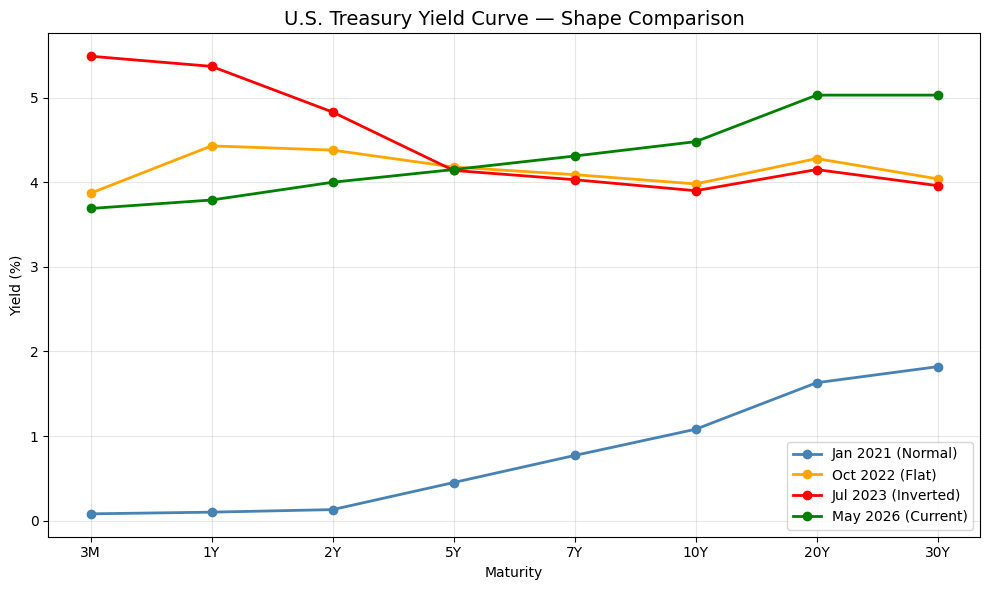

In [13]:
dates = {
    'Jan 2021 (Normal)': '2021-01-01',
    'Oct 2022 (Flat)': '2022-10-01',
    'Jul 2023 (Inverted)': '2023-07-01',
    'May 2026 (Current)': '2026-05-01',
}

maturity_labels = ['3M', '1Y', '2Y', '5Y', '7Y', '10Y', '20Y', '30Y']
colors = ['steelblue', 'orange', 'red', 'green']

fig, ax = plt.subplots(figsize=(10, 6))

for (label, date), color in zip(dates.items(), colors):
    row = curve_df.loc[date]
    ax.plot(maturity_labels, row[maturity_labels], marker='o',
            label=label, color=color, linewidth=2)

ax.set_title('U.S. Treasury Yield Curve — Shape Comparison', fontsize=14)
ax.set_xlabel('Maturity')
ax.set_ylabel('Yield (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
window = 24

df['spread_mean'] = df['spread'].rolling(window).mean()
df['spread_std'] = df['spread'].rolling(window).std()
df['z_score'] = (df['spread'] - df['spread_mean']) / df['spread_std']

print(df[['spread', 'z_score']].tail(5))

            spread   z_score
2026-01-01    0.67  1.261909
2026-02-01    0.66  1.143600
2026-03-01    0.54  0.755457
2026-04-01    0.52  0.636425
2026-05-01    0.48  0.451599


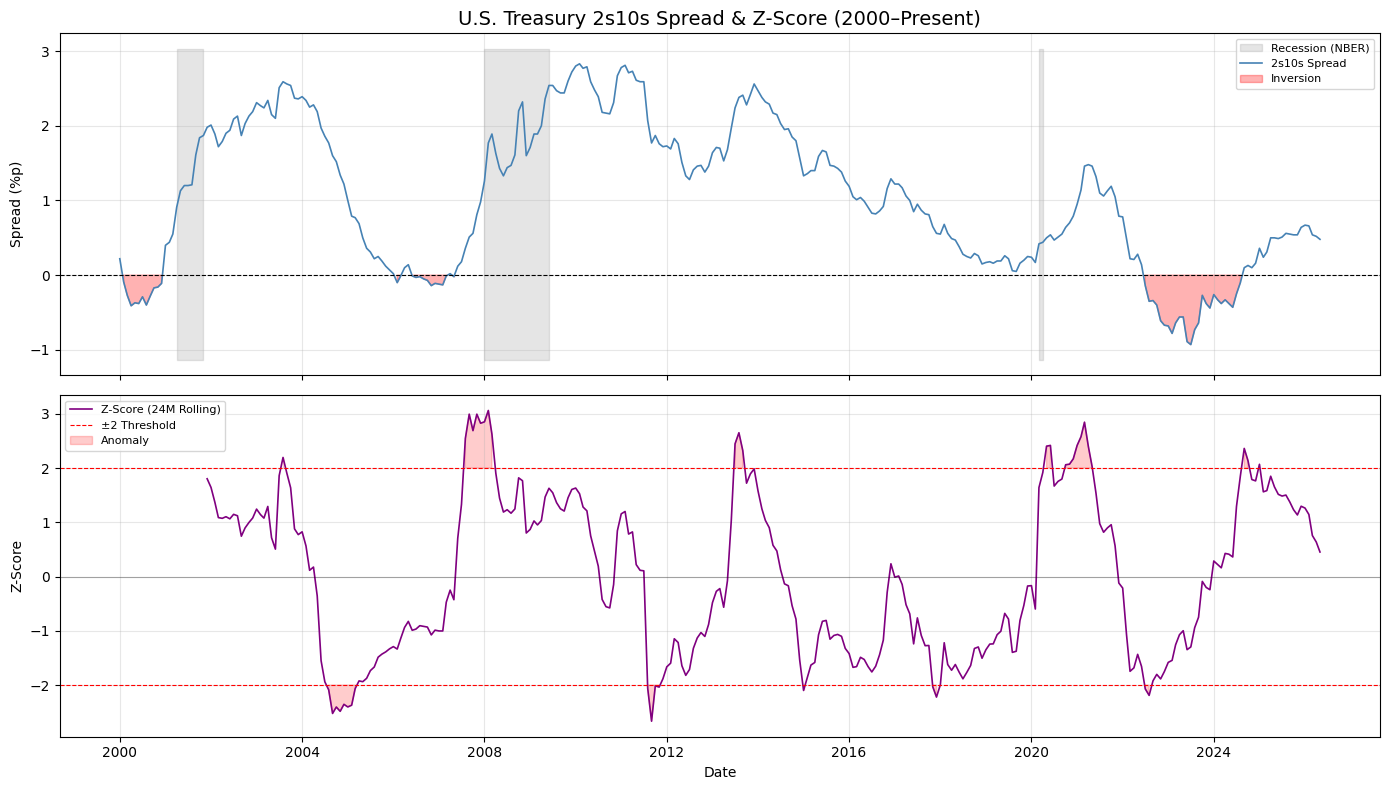

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.fill_between(df.index, df['spread'].min() - 0.2, df['spread'].max() + 0.2,
                 where=df['recession'] == 1,
                 color='gray', alpha=0.2, label='Recession (NBER)')
ax1.plot(df.index, df['spread'], color='steelblue', linewidth=1.2, label='2s10s Spread')
ax1.fill_between(df.index, df['spread'], 0,
                 where=df['inverted'], color='red', alpha=0.3, label='Inversion')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_ylabel('Spread (%p)')
ax1.set_title('U.S. Treasury 2s10s Spread & Z-Score (2000–Present)', fontsize=14)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax2.plot(df.index, df['z_score'], color='purple', linewidth=1.2, label='Z-Score (24M Rolling)')
ax2.axhline(2, color='red', linewidth=0.8, linestyle='--', label='±2 Threshold')
ax2.axhline(-2, color='red', linewidth=0.8, linestyle='--')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)
ax2.fill_between(df.index, df['z_score'], 2,
                 where=df['z_score'] > 2, color='red', alpha=0.2, label='Anomaly')
ax2.fill_between(df.index, df['z_score'], -2,
                 where=df['z_score'] < -2, color='red', alpha=0.2)
ax2.set_ylabel('Z-Score')
ax2.set_xlabel('Date')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
!mkdir -p ~/Desktop/python/yield_curve_analysis/analysis
!touch ~/Desktop/python/yield_curve_analysis/analysis/metrics.py